# Actividad 6 — Desigualdad espacial en la Región Metropolitana

**INF-497 · Análisis de Datos Espaciales**
**Sesión práctica · 29 abril (2 bloques)**

## Contexto

En la clase de hoy aplicamos a la RM las técnicas vistas en `06_desigualdad_espacial.ipynb` (basado en cap. 9 del libro *Geographic Data Science with Python*).

Trabajaremos con datos de la encuesta **CASEN 2017 y 2022** agregados a las **52 comunas** de la Región Metropolitana, ya preparados por el preámbulo. Tendremos dos definiciones de ingreso por comuna:

- **Ingreso autónomo per cápita** (`ypc_aut`): pre-transferencias estatales (sueldos, rentas, capital).
- **Ingreso total per cápita** (`ypc_tot`): post-transferencias (incluye subsidios y pensiones).

La gracia es que con esos datos podemos responder dos preguntas distintas:

1. *Temporal:* ¿la geografía de la desigualdad en RM cambió entre 2017 y 2022?
2. *Estructural:* ¿cuánto reducen las transferencias del Estado la desigualdad **espacial** (no solo la individual)?

## Reglas

- Suban este notebook con sus respuestas (código + texto en markdown) ejecutado.
- Las preguntas marcadas **Interpretación** se responden en celdas markdown — no basta con código.
- Si una comuna tiene `n < 200` en la muestra CASEN, el promedio comunal es ruidoso. Pueden discutir el efecto en sus respuestas.

## Requisito previo

El notebook **`06_actividad6_preambulo.ipynb`** generara el archivo `datos/external/casen_rm/casen_rm_comunas.gpkg`. Usan la CASEN 2017 Y 2022 de base. No lo necesitan ejecutar.

## 0. Setup

In [6]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import esda
from libpysal import weights
from inequality.gini import Gini, Gini_Spatial
from inequality.theil import Theil, TheilD

sns.set_context("notebook")

gdf = gpd.read_file("casen_rm_comunas.gpkg")
print(f"{len(gdf)} comunas RM cargadas | CRS: {gdf.crs}")
gdf.head(3)

52 comunas RM cargadas | CRS: EPSG:32719


,cod_comuna,nom_comuna,nom_prov,region,ypc_aut_2017,ypc_aut_2022,ypc_tot_2017,ypc_tot_2022,mediana_aut_2017,mediana_aut_2022,n_2017,n_2022,geometry
0,13404,PAINE,MAIPO,13,285365.876995,320527.047313,353275.520186,446774.840194,200000.0,254583.0,420.0,456.0,"POLYGON ((350033.92 6265707.472, 350106.705 62..."
1,13402,BUIN,MAIPO,13,215822.686195,388319.809053,272555.328224,502456.613901,172000.0,280000.0,392.0,602.0,"POLYGON ((348666.339 6275861.274, 348652.409 6..."
2,13124,PUDAHUEL,SANTIAGO,13,235630.811008,400037.613058,297166.493830,515095.307407,195167.0,313750.0,935.0,1299.0,"POLYGON ((333540.425 6307203.281, 333624.972 6..."


---

## Ejercicio 1 — Exploración inicial

Antes de calcular métricas, vamos a ver con qué tipo de distribución estamos trabajando y qué patrones espaciales saltan a la vista.

### 1.A — Histogramas

Visualice en una grilla de 2x2  histogramas de las cuatro variables de ingreso (`ypc_aut_2017`, `ypc_aut_2022`, `ypc_tot_2017`, `ypc_tot_2022`). Agregue títulos claros.

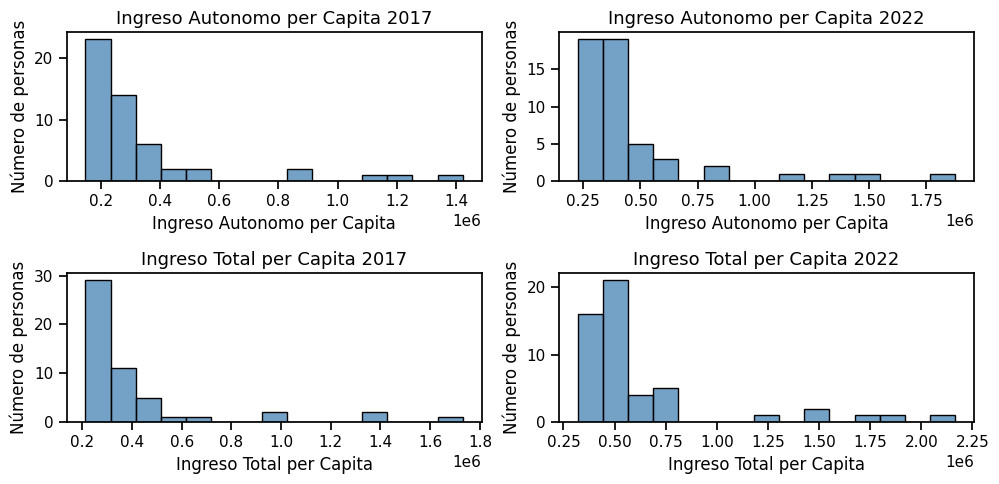

In [28]:
# Tu código aquí
fig, axs = plt.subplots(2, 2, figsize=(10, 5))
ax1, ax2 = axs[0]
ax3, ax4 = axs[1]


# Histograma
sns.histplot(
    gdf["ypc_aut_2017"],
    ax=ax1,             
    color="steelblue")

ax1.set_title("Ingreso Autonomo per Capita 2017", fontsize=13)
ax1.set_xlabel("Ingreso Autonomo per Capita")
ax1.set_ylabel("Número de personas")
plt.tight_layout()


# Histograma
sns.histplot(
    gdf["ypc_aut_2022"],
    ax=ax2,             
    color="steelblue")

ax2.set_title("Ingreso Autonomo per Capita 2022", fontsize=13)
ax2.set_xlabel("Ingreso Autonomo per Capita")
ax2.set_ylabel("Número de personas")
plt.tight_layout()

# Histograma
sns.histplot(
    gdf["ypc_tot_2017"],
    ax=ax3,             
    color="steelblue")

ax3.set_title("Ingreso Total per Capita 2017", fontsize=13)
ax3.set_xlabel("Ingreso Total per Capita")
ax3.set_ylabel("Número de personas")
plt.tight_layout()


# Histograma
sns.histplot(
    gdf["ypc_tot_2022"],
    ax=ax4,             
    color="steelblue")

ax4.set_title("Ingreso Total per Capita 2022", fontsize=13)
ax4.set_xlabel("Ingreso Total per Capita")
ax4.set_ylabel("Número de personas")
plt.tight_layout()
plt.show()

---

## Ejercicio 2 — Medidas globales de desigualdad

Calculen los tres índices clásicos para las cuatro combinaciones (autónomo / total × 2017 / 2022) y comparen.

### 2.A — Gini, Theil y Ratio 20:20

Construya un DataFrame `indices` con índice las 4 combinaciones (`aut_2017`, `aut_2022`, `tot_2017`, `tot_2022`) y columnas `gini`, `theil`, `ratio_20_20`.

Usen:
- `inequality.gini.Gini(valores).g` para Gini
- `inequality.theil.Theil(valores).T` para Theil
- Cálculo manual del ratio 20:20: `Q80 / Q20`

In [38]:
# Tu código aquí
def ratio2020(columna):
    top20, bot80 = gdf[columna].quantile([0.8, 0.2])
    return top20/bot80

def gini(values):
    return Gini(gdf[values]).g

def theil(values):
    return Theil(gdf[values]).T


data = {
    "id":['aut_2017','aut_2022','tot_2017','tot_2022'] ,
    "ratio_2020": [ratio2020('ypc_aut_2017'),ratio2020('ypc_aut_2022'),ratio2020('ypc_tot_2017'),ratio2020('ypc_tot_2022')],
    "gini": [gini('ypc_aut_2017'),gini('ypc_aut_2022'),gini('ypc_tot_2017'),gini('ypc_tot_2022')],
    "theil": [theil('ypc_aut_2017'),theil('ypc_aut_2022'),theil('ypc_tot_2017'),theil('ypc_tot_2022')],
}

df = pd.DataFrame(data)
print(df)

         id  ratio_2020      gini     theil
0  aut_2017    1.813183  0.316272  0.207756
1  aut_2022    1.693261  0.286125  0.169940
2  tot_2017    1.715878  0.290560  0.181807
3  tot_2022    1.726886  0.266499  0.146869


C:\Users\dacisternasp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\inequality\gini.py:43: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  x = x.ravel()  # ensure shape is (n,)


### 2.B — Curvas de Lorenz comparadas

Grafiquen en **un solo eje** las 4 curvas de Lorenz (use distintos colores y tipos de línea — autónomo en sólido, total en punteado, 2017 en azul, 2022 en naranja, por ejemplo). Incluyan la diagonal de igualdad perfecta.

Pueden utilizar la función `lorenz(y)` 

```python
 def lorenz(y):
    y_sorted = np.sort(np.asarray(y))
    cum_y = (y_sorted / y_sorted.sum()).cumsum()
    cum_p = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    return cum_p, cum_y
```

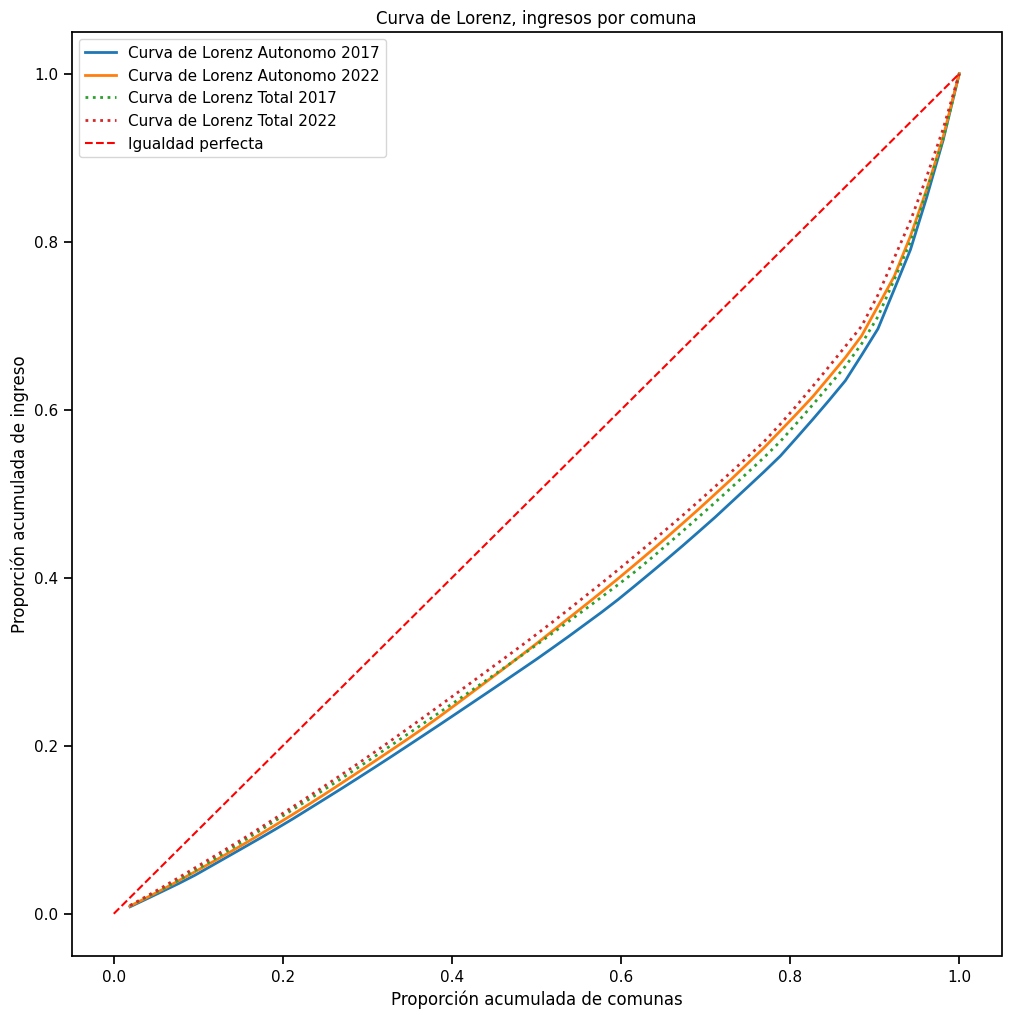

In [47]:
# Tu código aquí
def lorenz(y):
    y_sorted = np.sort(np.asarray(y))
    cum_y = (y_sorted / y_sorted.sum()).cumsum()
    cum_p = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    return cum_p, cum_y
#cum_p proporcion de poblacion
#cum_y proporcion de ingreso
cum_p_aut17, cum_y_aut17 = lorenz(gdf['ypc_aut_2017'])
cum_p_aut22, cum_y_aut22 = lorenz(gdf['ypc_aut_2022'])
cum_p_tot17, cum_y_tot17 = lorenz(gdf['ypc_tot_2017'])
cum_p_tot22, cum_y_tot22 = lorenz(gdf['ypc_tot_2022'])

fig, ax = plt.subplots(figsize=(12,12))

ax.plot(cum_p_aut17, cum_y_aut17,label="Curva de Lorenz Autonomo 2017", linewidth=2,  linestyle='-')
ax.plot(cum_p_aut22, cum_y_aut22,label="Curva de Lorenz Autonomo 2022", linewidth=2,   linestyle='-')
ax.plot(cum_p_tot17, cum_y_tot17,label="Curva de Lorenz Total 2017", linewidth=2,   linestyle=':')
ax.plot(cum_p_tot22, cum_y_tot22,label="Curva de Lorenz Total 2022", linewidth=2, linestyle=':')

ax.plot([0, 1], [0, 1], color="red", linestyle="--",label="Igualdad perfecta")


#ax.fill_between(cum_p, cum_p,cum_y, alpha=0.2)
ax.set_xlabel("Proporción acumulada de comunas")
ax.set_ylabel("Proporción acumulada de ingreso")
ax.set_title("Curva de Lorenz, ingresos por comuna")
ax.legend()
plt.show()

### 2.C — Interpretación

1. ¿La desigualdad **subió o bajó** entre 2017 y 2022 según los tres índices? ¿Coinciden?
2. Comparen ingreso autónomo vs total dentro del **mismo año**. ¿Cuánto reducen las transferencias del Estado la desigualdad **entre comunas**? Cuantifíquenlo (ej. caída porcentual del Gini).

**Respuesta 2.C:** *(escriban acá)*

1) Según lo mostrado por el gráfico de las curvas de lorenz, en el año 2022 la desigualdad bajó aunque muy levemente según los gráficos y según los indices.

2) Las transferencias del estado hacen que los ingresos sean menos desiguales, en ambos años 2017 y 2022 los inidces de Gini y de Theil bajaron si comparamos el ingreso autónomo vs el total, el 2017 el indice de Gini bajó un 0.026 y el de Theil bajó igualmente un 0.026, lo cual significa que las ayudas tipo subsidio del estado benefician a que los ingreos sean menos desiguales, sin embargo sigue siendo un leve cambio.

---

## Ejercicio 3 — Descomposición regional del Theil por provincia

A diferencia del notebook 06 (que descomponía el Theil por las 8 regiones censales de EE.UU.), nosotros descompondremos por las **6 provincias** de la RM (Santiago, Cordillera, Maipo, Chacabuco, Talagante, Melipilla). La pregunta que respondemos: *¿cuánta de la desigualdad entre comunas RM viene de diferencias entre provincias, y cuánta de diferencias dentro de cada provincia?*

### 3.A — Calcular el Theil total y su descomposición

Para el ingreso autónomo per cápita 2022 (`ypc_aut_2022`):

1. Calculen el **Theil total** con `inequality.theil.Theil(...).T`.
2. Calculen `inequality.theil.TheilD(valores, gdf['nom_prov'].values)` y reporten:
   - `theil_entre = .bg`  — diferencias entre provincias
   - `theil_dentro = .wg` — diferencias dentro de provincias
   - `proporción entre = theil_entre / theil_total`

In [61]:
# Tu código aquí
theil = Theil(gdf['ypc_aut_2022']).T

theil_entre = TheilD(gdf['ypc_aut_2022'], gdf['nom_prov'].values).bg
theil_dentro = TheilD(gdf['ypc_aut_2022'], gdf['nom_prov'].values).wg

print(f"El Indice de Theil total es de: {theil} \nEl inidice de theil entre provincias es: {theil_entre[0]} \nEl indice de theil dentro de provincias es: {theil_dentro[0]}")

El Indice de Theil total es de: 0.16994046463349205 
El inidice de theil entre provincias es: 0.02227864574153056 
El indice de theil dentro de provincias es: 0.1476618188919615


### 3.B — Mapa de las provincias

Hagan un mapa de la RM coloreando cada comuna por su provincia:

```python
gdf.plot("nom_prov", categorical=True, legend=True, edgecolor="white", figsize=(9, 7))
```

Esto les da contexto visual: ¿cuántas comunas tiene cada provincia? ¿Hay provincias homogéneas y otras muy mezcladas?

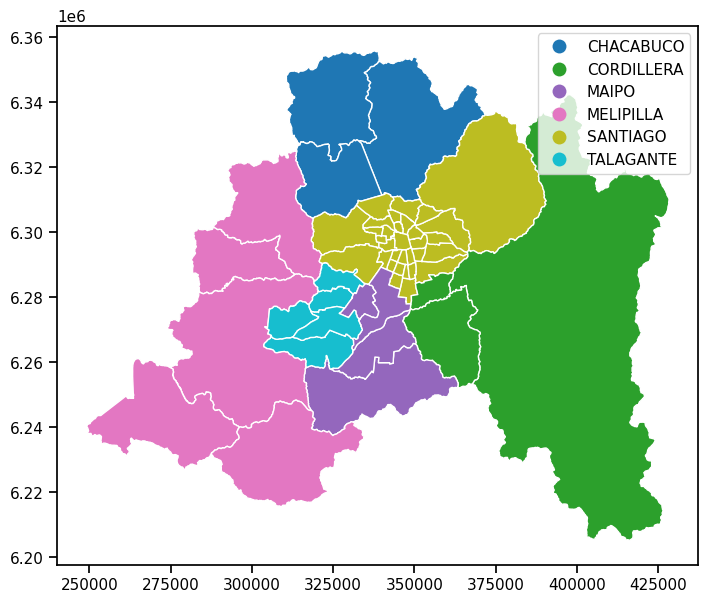

In [62]:
# Tu código aquí
gdf.plot("nom_prov", categorical=True, legend=True, edgecolor="white", figsize=(9, 7))
plt.show()

### 3.C — Interpretación

Respondan en una celda markdown:

1. ¿Qué porcentaje del Theil viene de diferencias **entre** provincias vs **dentro** de provincias? ¿Qué les dice ese número?

2. ¿Tiene sentido el resultado dado el mapa? 

3. ¿Qué pasaría con la proporción `entre / total` si en vez de provincias descompusiéramos por las 6 zonas geográficas tradicionales del Gran Santiago (oriente, surponiente, etc.)? **No lo calculen — solo razonen.**

**Respuesta 3.C:** *(escriban acá)*

1) El porcentaje mayor viene desde la diferencias dentro de provincias, esto significa que hay mucha mas desigualdad dentro de las comunas que están dentro de las provincias (ej: las condes y renca), esto puede significar que hay comunas con muchos mas recursos que otras, pero la desigualdad "general" de las comunas es similar.

2) 

3) Seguramente si descomponemos las zonas geográficas tradicionalmente (oriente, surponiente) habría un indice de de Theil entre provincias mayor, ya que hay zonas de la RM que concentran una mayor "riqueza". Y es posible que no haya tanta desigualdad entre las provincias.